### To run scRNA-seq analysis for melanoma patients

Reference: https://www.nature.com/articles/s41467-022-34877-3

data source: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE215121

https://ftp.ncbi.nlm.nih.gov/geo/series/GSE215nnn/GSE215121/

CHETAH tumor reference and input data:
https://figshare.com/ndownloader/articles/6994007?private_link=aaf026376912366f81b6

https://nbisweden.github.io/excelerate-scRNAseq/session-celltypeid/celltypeid.html

In [1]:
# Set up
required.packages <- c("Seurat", "dplyr", "SingleR", "celldex", "SingleCellExperiment",
                       "glue", 'readxl', 'cowplot', 'ggplot2', 'viridis', 'tidyr', 
                       'harmony', 'Azimuth', 'SeuratData', 'rio', 'Matrix', 'celldex', 'SingleR', 'scuttle') 

# if(!requireNamespace('remotes', quietly = TRUE)){
#   install.packages('remotes')}
#   
# remotes::install_github('satijalab/azimuth', ref = 'master')
# devtools::install_github('satijalab/seurat-data')
# devtools::install_github("navinlabcode/copykat")

new.packages <- required.packages[!(required.packages %in% installed.packages()[,"Package"])]

if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")


if(length(new.packages) > 0 ) BiocManager::install(new.packages)

sapply(required.packages, function(pkg){suppressPackageStartupMessages(require(pkg, character.only = TRUE))})

Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')



Seurat                dplyr              SingleR 
                TRUE                 TRUE                 TRUE 
             celldex SingleCellExperiment                 glue 
                TRUE                 TRUE                 TRUE 
              readxl              cowplot              ggplot2 
                TRUE                 TRUE                 TRUE 
             viridis                tidyr              harmony 
                TRUE                 TRUE                 TRUE 
             Azimuth           SeuratData                  rio 
                TRUE                 TRUE                 TRUE 
              Matrix              celldex              SingleR 
                TRUE                 TRUE                 TRUE 
             scuttle 
                TRUE

In [2]:
data.dir <- "/media/josh/seagate/data/perm/scRNA_seq/Zhang_melanoma"

if(!dir.exists(data.dir)){
    dir.create(data.dir, recursive = T)
}

date.str <- "05132023"

project = 'melanoma'

nFeature_lower <- 250
nFeature_upper <- 10000
nCount_lower <- 1000
nCount_upper <- 100000
pMT_lower <- 0
pMT_upper <- 25
pHB_lower <- 0
pHB_upper <- 5

In [3]:

URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE215nnn/GSE215121/suppl/GSE215121_RAW.tar'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}



URL <- 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE215nnn/GSE215121/matrix/GSE215121-GPL20795_series_matrix.txt.gz'
file_name <- basename(URL)

if(!file.exists(glue('{data.dir}/{file_name}'))){
  system(sprintf("wget '%s' -P %s", URL, data.dir))
  # system(sprintf('tar -xvf %s/%s -C %s', data.dir, file_name, data.dir))
  # system(glue('rm {data.dir}/{file_name}'))
}



In [4]:
# URL <- 'https://figshare.com/ndownloader/files/34702012'
# dest_path <- '/media/joshu/seagate/data/perm/scRNA_seq/human_refs/TS_Skin.h5ad.zip'
# file_dir <- dirname(dest_path)
# file_name <- gsub('.zip', '', basename(dest_path))
# if(!file.exists(glue('{file_dir}/{file_name}'))){
#     download.file(URL, dest_path, method = 'wget')
#     unzip(dest_path,exdir=file_dir)
#     system(glue('rm {dest_path}'))
# }



ERROR: Error in download.file(URL, dest_path, method = "wget"): 'wget' call had nonzero exit status


In [5]:
raw.data <- Read10X("/datanew/scRNA_seq/human_refs/TS_Skin/matrix_files")
meta <- read.csv("/datanew/scRNA_seq/human_refs/TS_Skin/matrix_files/metadata.csv", row.names = 1)



In [6]:
ref.obj <- CreateSeuratObject(raw.data)
if(all(row.names(ref.obj@meta.data) == row.names(meta))){
    
    ref.obj <- AddMetaData(ref.obj, metadata = meta)

}

In [7]:
# ref.obj <- logNormCounts(ref.obj)
ref.obj <- as.SingleCellExperiment(DietSeurat(ref.obj))

ref.obj <- logNormCounts(ref.obj)


In [8]:
dat <- GEOquery::getGEO(filename=glue('{data.dir}/GSE215121-GPL20795_series_matrix.txt.gz'),GSEMatrix = FALSE,getGPL = FALSE)

meta <- pData(dat)

pheno <- meta %>% select(title, geo_accession, source_name_ch1,  
                         'supplementary_file_1', 'genotype:ch1', 'tissue:ch1', 'treatment:ch1')


pheno <- data.table::setnames(pheno, c('source_name_ch1', 'genotype:ch1', 'tissue:ch1', 'treatment:ch1'), 
                              c('Tissue_type', 'ca_subtypes', 'Tissue', 'Treatment')) %>% unique()

# pheno$sample_name <- paste0(pheno$geo_accession, '_', pheno$title)
# pheno$patient_id <- sapply(strsplit(pheno$title, '_'), '[', 1)
# pheno$disease_type[pheno$Diagnosis == 'Lung adenocarcinoma'] <- 'LUAD'
# pheno$disease_type[pheno$Diagnosis == 'Lung squamous cell carcinoma'] <- 'LUSC'
# pheno$disease_type[pheno$Tissue_type == 'Adjacent normal'] <- 'Normal'
# pheno$Tissue_type[pheno$Tissue_type == 'Adjacent normal'] <- 'Normal'
# pheno$Tissue_type[pheno$Tissue_type == 'tumor'] <- 'Tumor'
# pheno <- pheno %>% select(patient_id, geo_accession, Tissue_type, Sex, sample_name, disease_type, supplementary_file_1) %>% filter(patient_id == 'P2')

pheno$Treatment <- gsub('with anti-PD1 treatment', 'Anti-PD1', pheno$Treatment)
pheno$Treatment <- gsub('no-treatment', 'Untreated', pheno$Treatment)
pheno$ca_subtypes <- gsub(' melanoma', '', pheno$ca_subtypes)


Setting options('download.file.method.GEOquery'='auto')

Setting options('GEOquery.inmemory.gpl'=FALSE)



In [9]:

create_seurat_object <- function(i){
    prj <- pheno$geo_accession[i]
    file_name <- basename(pheno$supplementary_file_1[i])
    # smp <- gsub('_processed_data.txt.gz', '', file_name)

    # file_dir <- glue('{data.dir}/{smp}/')

    # exp_mtx <- ReadMtx(
    #     mtx = glue("{file_dir}/matrix.mtx.gz"), 
    #     features = glue("{file_dir}/features.tsv.gz"),
    #     cells = glue("{file_dir}/barcodes.tsv.gz"), 
    #     skip.cell = 1, skip.feature = 1)
    # exp_mtx <- Read10X(data.dir = file_dir)
    
    # cnts <- read.table(glue('{data.dir}/{file_name}'), sep = "\t", row.names=1, header=T)
    # cnts <- Matrix(as.matrix(cnts), sparse=T)
    cnts <- Read10X_h5(glue('{data.dir}/{file_name}'))

    # seurat_obj <- CreateSeuratObject(counts = exp_mtx, project = prj)
    seurat_obj <- CreateSeuratObject(counts = cnts, project = prj)

    return(seurat_obj)

}

seu_obj_list <- lapply(seq_along(pheno$geo_accession), create_seurat_object)
# seu_obj_list <- lapply(1:3, create_seurat_object)

gc()
# seu_obj <- Reduce(function(x,y) merge(x,y, add.cell.ids = c(x@project.name, y@project.name)) , seu_obj_list )
seu_obj <- merge(seu_obj_list[[1]], y = c(unlist(seu_obj_list))[2:length(seu_obj_list)], add.cell.ids = pheno$geo_accession, project = project)                        

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9727211,519.5,14688662,784.5,13518220,722
Vcells,464206275,3541.7,687483615,5245.1,657839411,5019


In [10]:
gc()
### calculate mitochondrial, hemoglobin and ribosomal gene counts
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^MT-", col.name = "pMT")
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^HBA|^HBB", col.name = "pHB")
seu_obj <- PercentageFeatureSet(seu_obj, pattern = "^RPS|^RPL", col.name = "pRP")

# Data Filtering 

seu_obj_filtered <- subset(seu_obj, subset = nFeature_RNA > nFeature_lower & nFeature_RNA < nFeature_upper & pMT < pMT_upper )


seu_obj_filtered

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9845434,525.9,14688662,784.5,13518220,722.0
Vcells,1211176891,9240.6,2565242808,19571.3,2035488329,15529.6


An object of class Seurat 
33538 features across 96292 samples within 1 assay 
Active assay: RNA (33538 features, 0 variable features)

In [11]:
meta_data <- seu_obj_filtered@meta.data
meta_data$cells <- row.names(meta_data)

pheno$supplementary_file_1 <- NULL
meta_data <- merge(meta_data, pheno, by.x = 'orig.ident', by.y = 'geo_accession', all.x = T)
row.names(meta_data) <- meta_data$cells
meta_data$cells <- NULL


if(all(row.names(meta_data) == row.names(seu_obj_filtered@meta.data))){
    
    seu_obj_filtered <- AddMetaData(object = seu_obj_filtered, meta = meta_data)

}

head(seu_obj_filtered@meta.data, 2)

,orig.ident,nCount_RNA,nFeature_RNA,pMT,pHB,pRP,title,Tissue_type,ca_subtypes,Tissue,Treatment
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM6622292_AAACCTGAGCAGCGTA-1,GSM6622292,34962,5254,12.708083,0,15.11355,melanoma scRNA Acral1,human tumor,acral,human tumor,Untreated
GSM6622292_AAACCTGAGCCCAATT-1,GSM6622292,2788,1032,1.470588,0,28.04878,melanoma scRNA Acral1,human tumor,acral,human tumor,Untreated


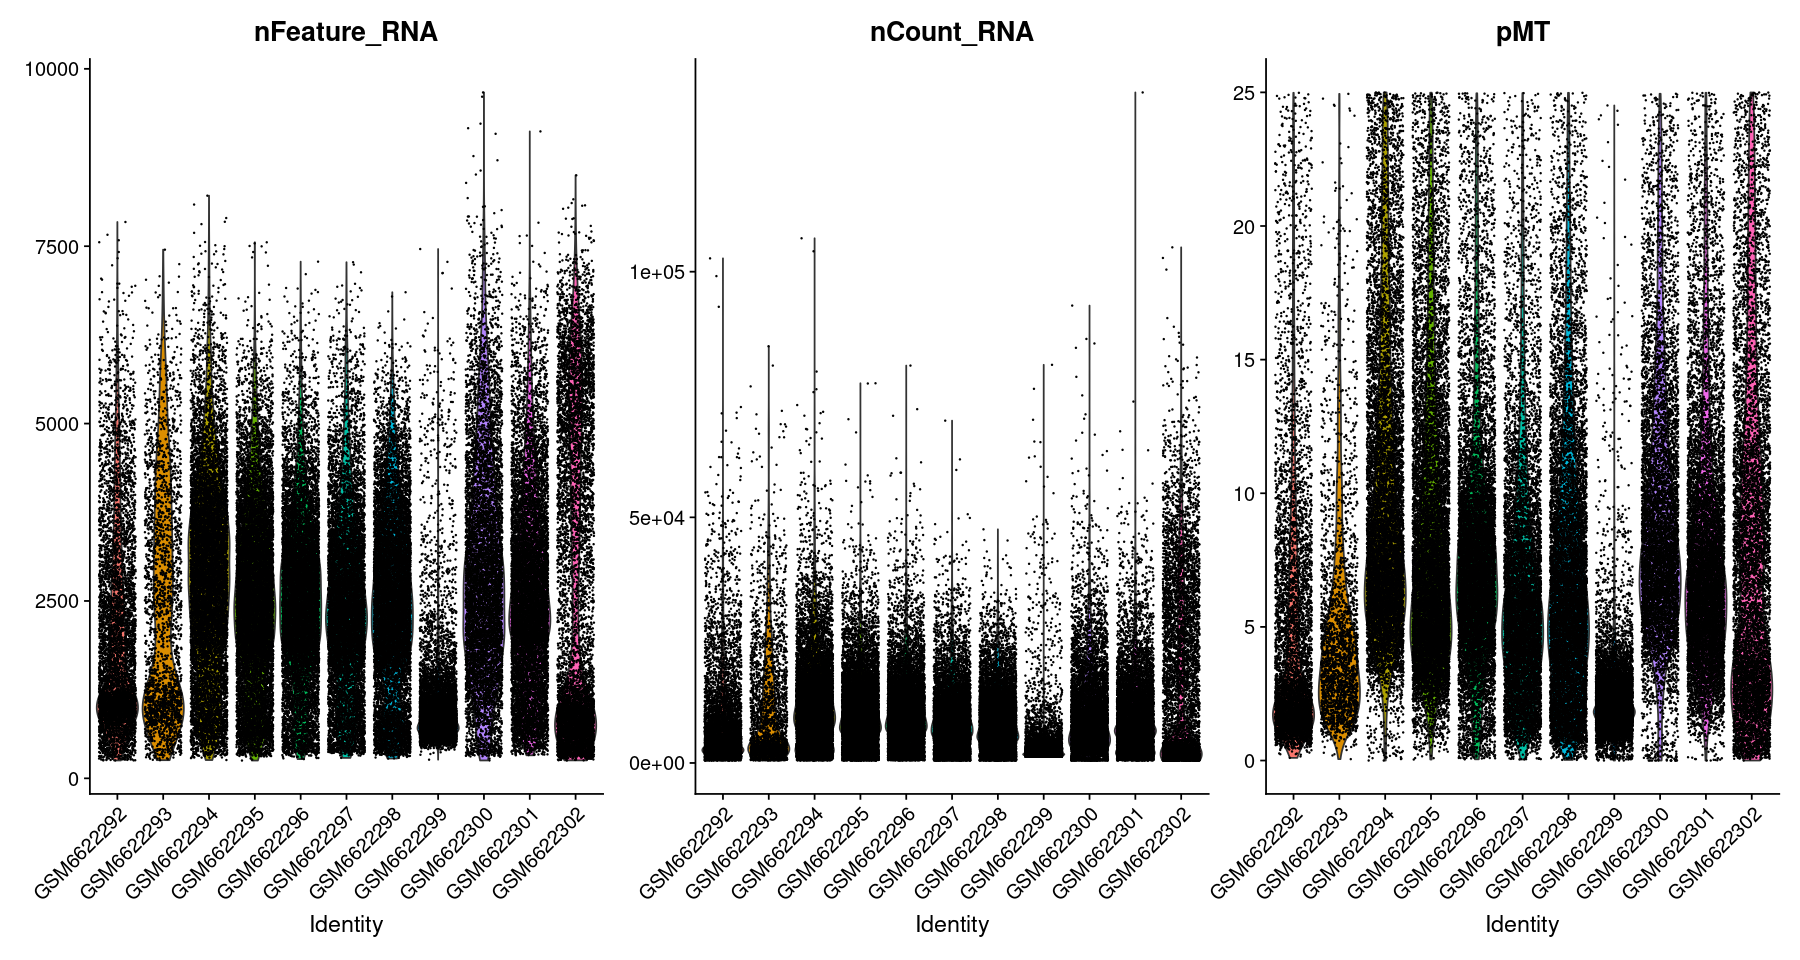

In [12]:
options(repr.plot.width = 15, repr.plot.height = 8)
VlnPlot(seu_obj_filtered, features = c("nFeature_RNA", "nCount_RNA", "pMT"), ncol = 3)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9966338,532.3,14688662,784.5,14688662,784.5
Vcells,1920728395,14654.0,3078371369,23486.2,2274232792,17351.1


Will not return corrected UMI because residual type is not set to 'pearson'



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,10042447,536.4,14688662,784.5,14688662,784.5
Vcells,2837126224,21645.6,6383740308,48704.1,6383669708,48703.6


Warning message:
“Invalid name supplied, making object name syntactically valid. New object name is Seurat..ProjectDim.SCT.harmony; see ?make.names for more details on syntax validity”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


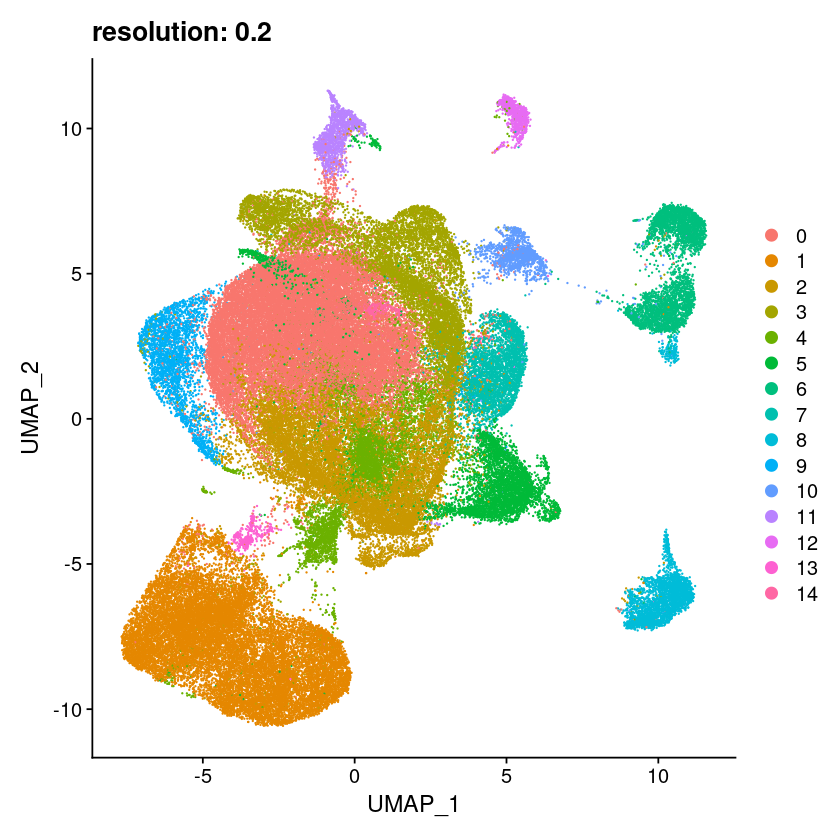

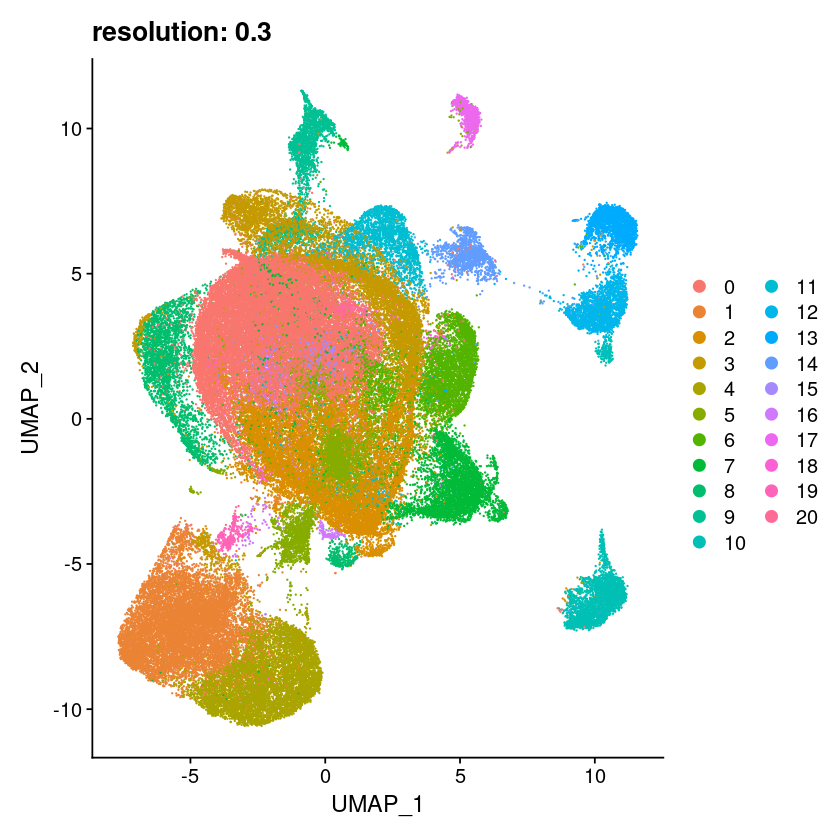

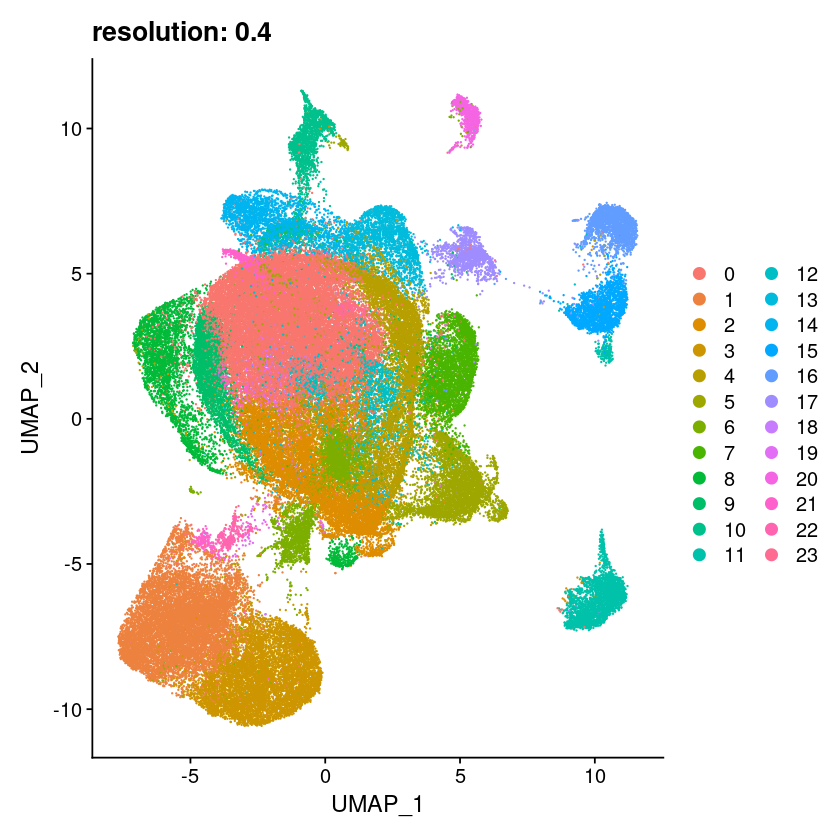

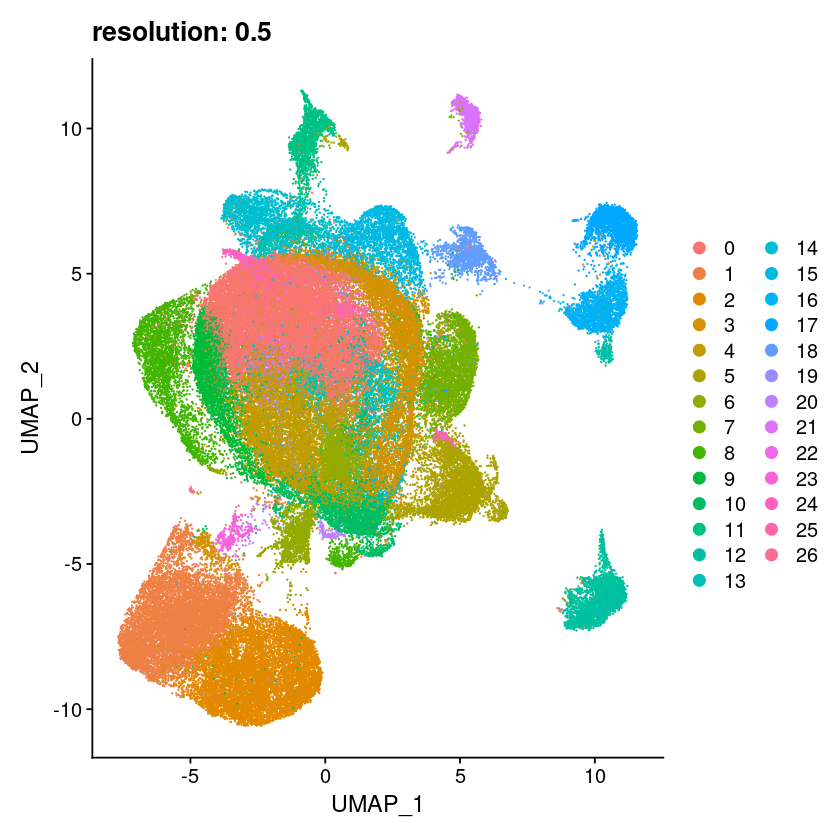

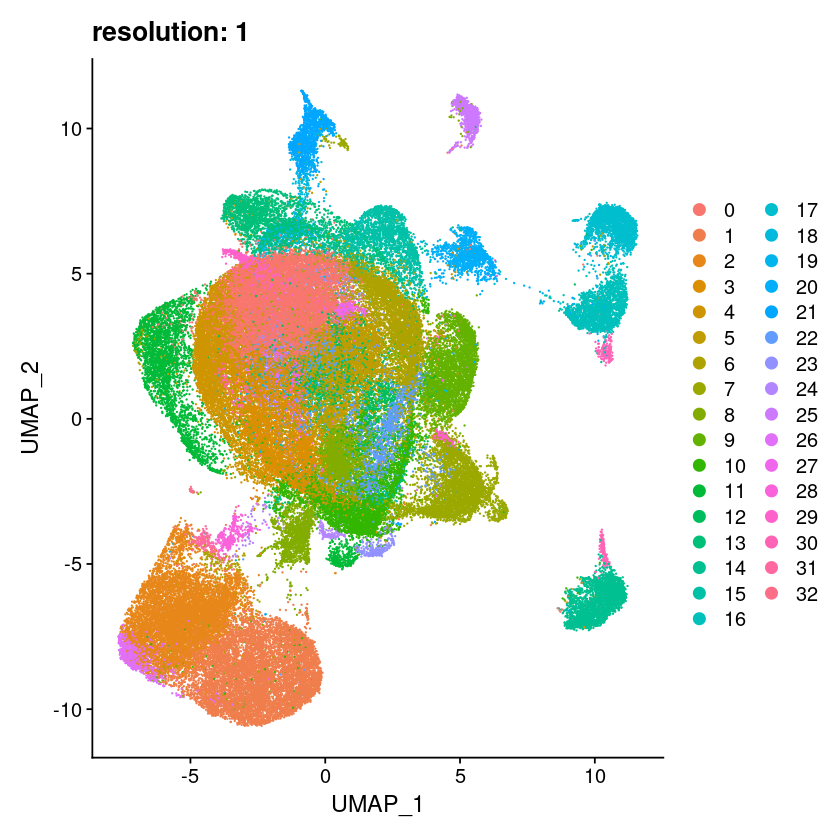

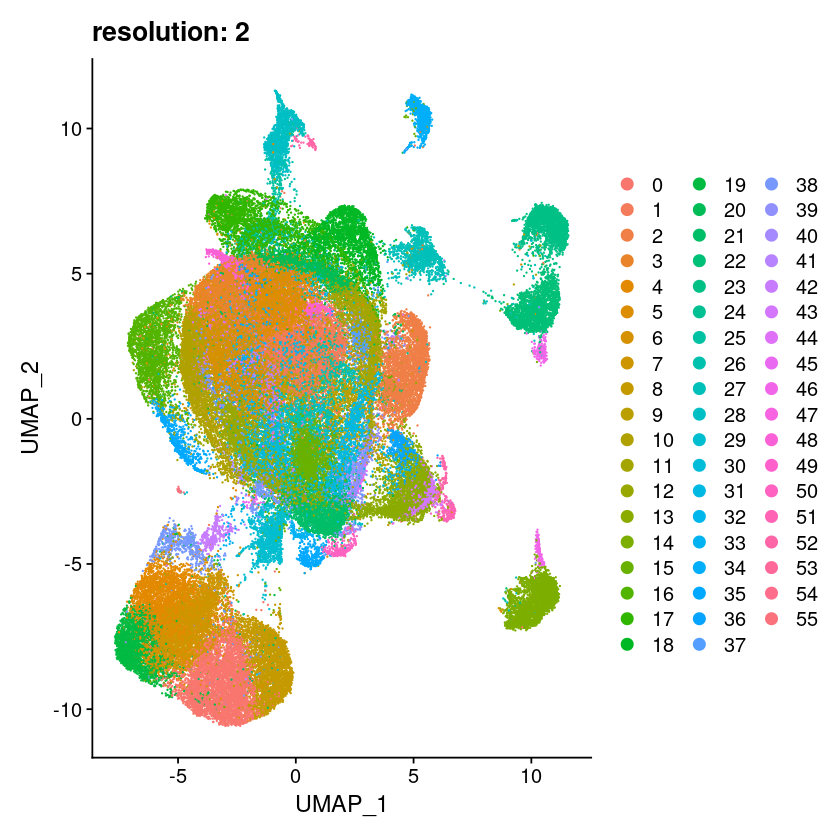

In [13]:
options(repr.plot.width = 7, repr.plot.height = 7)
# Data normalization
gc()
seu_obj_filtered <- SCTransform(seu_obj_filtered, verbose = FALSE, vars.to.regress = c("nCount_RNA", "pMT"), conserve.memory = T)

gc()
# Dimensionality reduction
seu_obj_filtered <- RunPCA(seu_obj_filtered, verbose = FALSE)

seu_obj_filtered <- seu_obj_filtered %>% 
    RunHarmony("orig.ident", plot_convergence = FALSE, assay.use = "SCT", verbose = FALSE)

# seu_obj_filtered <- RunUMAP(seu_obj_filtered, reduction = "harmony")
seu_obj_filtered <- seu_obj_filtered %>% 
    RunUMAP(reduction = "harmony", dims = 1:20, verbose = FALSE) %>% 
    FindNeighbors(reduction = "harmony", dims = 1:20, verbose = FALSE)

for (i in c(0.2, 0.3, 0.4, 0.5, 1, 2)) {
  seu_obj_filtered <- FindClusters(seu_obj_filtered, resolution = i, verbose = FALSE)
  print(DimPlot(seu_obj_filtered, reduction = "umap") + labs(title = paste0("resolution: ", i)))
}


In [14]:
rm(seu_obj_list, seu_obj)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9979312,533.0,14688662,784.5,14688662,784.5
Vcells,1738980338,13267.4,5106992247,38963.3,6383669708,48703.6


In [15]:
sce <- as.SingleCellExperiment(DietSeurat(seu_obj_filtered))
sce

class: SingleCellExperiment 
dim: 25995 96292 
metadata(0):
assays(2): counts logcounts
rownames(25995): MIR1302-2HG OR4F5 ... AC004556.1 AC240274.1
rowData names(0):
colnames(96292): GSM6622292_AAACCTGAGCAGCGTA-1
  GSM6622292_AAACCTGAGCCCAATT-1 ... GSM6622302_TTTGTTGTCGAGAGAC-1
  GSM6622302_TTTGTTGTCTCGAACA-1
colData names(21): orig.ident nCount_RNA ... SCT_snn_res.2 ident
reducedDimNames(0):
mainExpName: SCT
altExpNames(1): RNA

In [ ]:
pred <- SingleR(test = sce, 
                assay.type.test = 1, 
                ref = ref.obj, 
                labels = ref.obj$cell_ontology_class, 
                BPPARAM = BiocParallel::MulticoreParam(parallel::detectCores()))

In [ ]:
# Add the annotated cell types to meta data of Seurat object
seu_obj_filtered@meta.data$cell.type <- pred$pruned.labels



In [5]:
# saveRDS(seu_obj_filtered, glue('{data.dir}/Zhang_melanoma.rds'))
seu_obj_filtered <- readRDS(glue('{data.dir}/Zhang_melanoma.rds'))

In [6]:
sorted_factors <- names(sort(table(seu_obj_filtered@meta.data$cell.type), 
                             decreasing = T))
seu_obj_filtered$cell.type <- factor(seu_obj_filtered$cell.type, levels = sorted_factors)

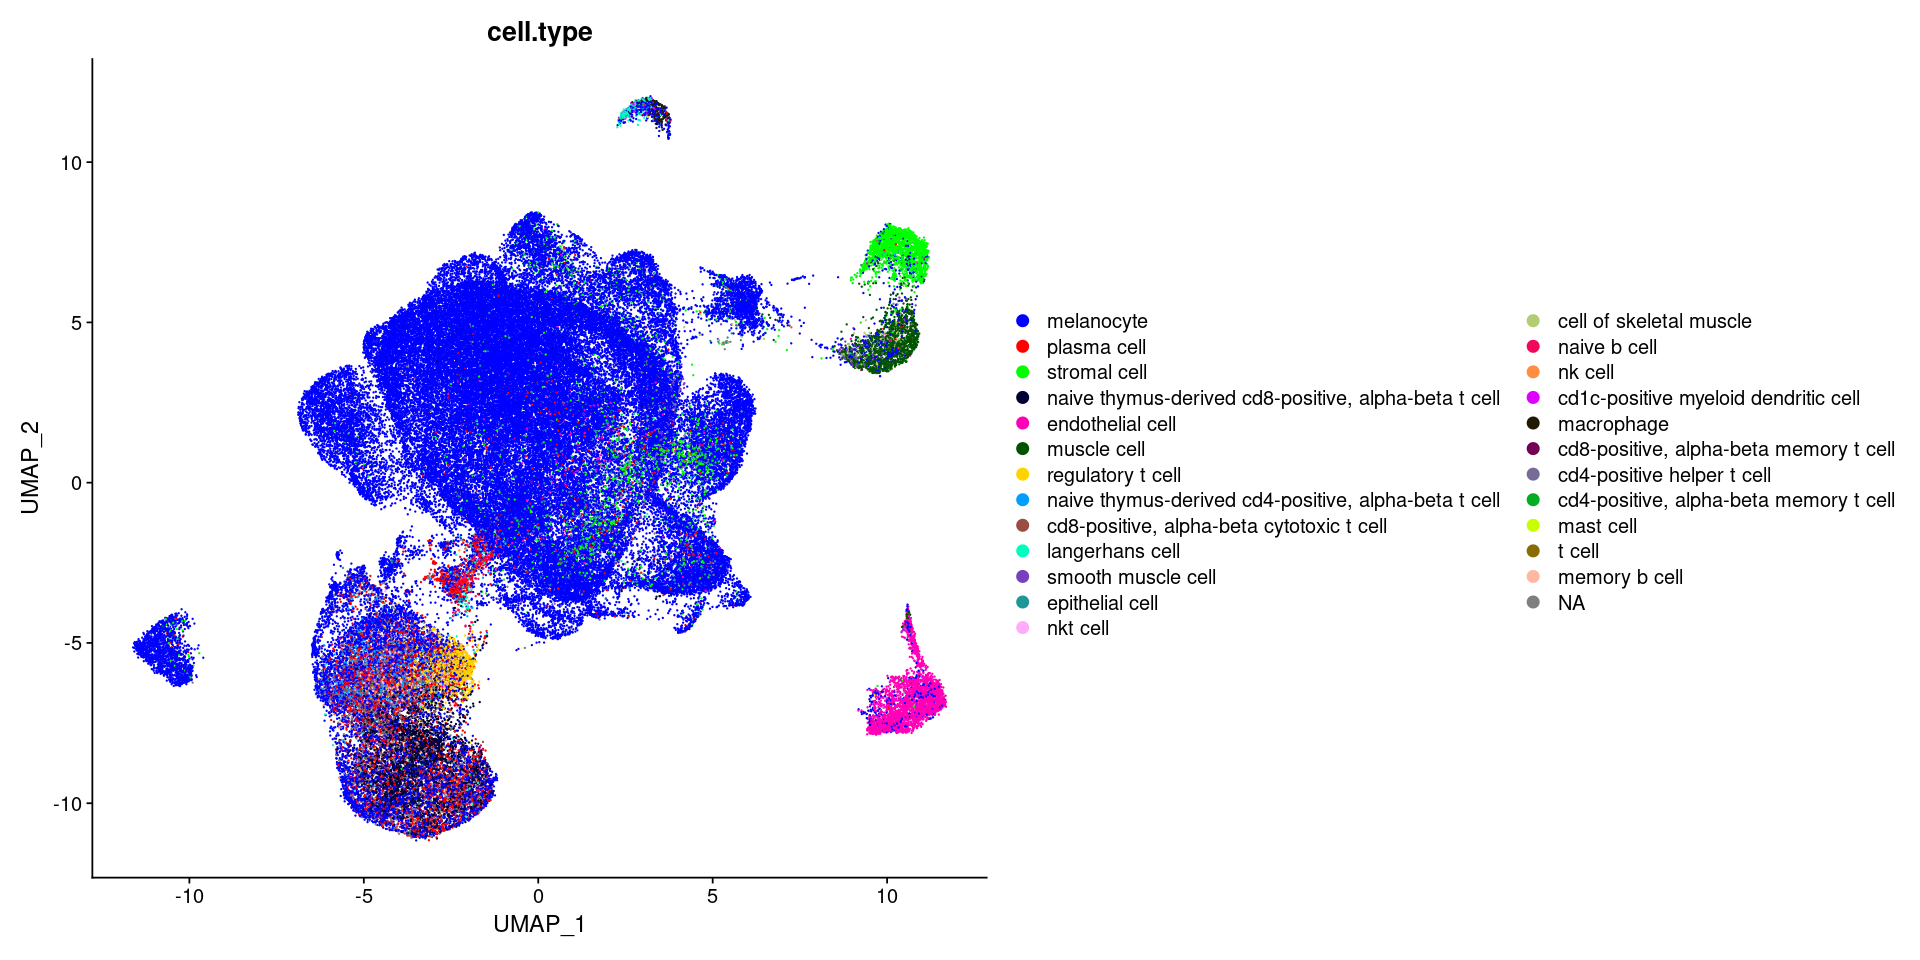

In [7]:
options(repr.plot.width = 16, repr.plot.height = 8)

n_colors <- length(unique(seu_obj_filtered@meta.data$cell.type))
colors <- DiscretePalette(n_colors, palette = "glasbey")
DimPlot(seu_obj_filtered, group.by = "cell.type", label = FALSE,  cols = colors)

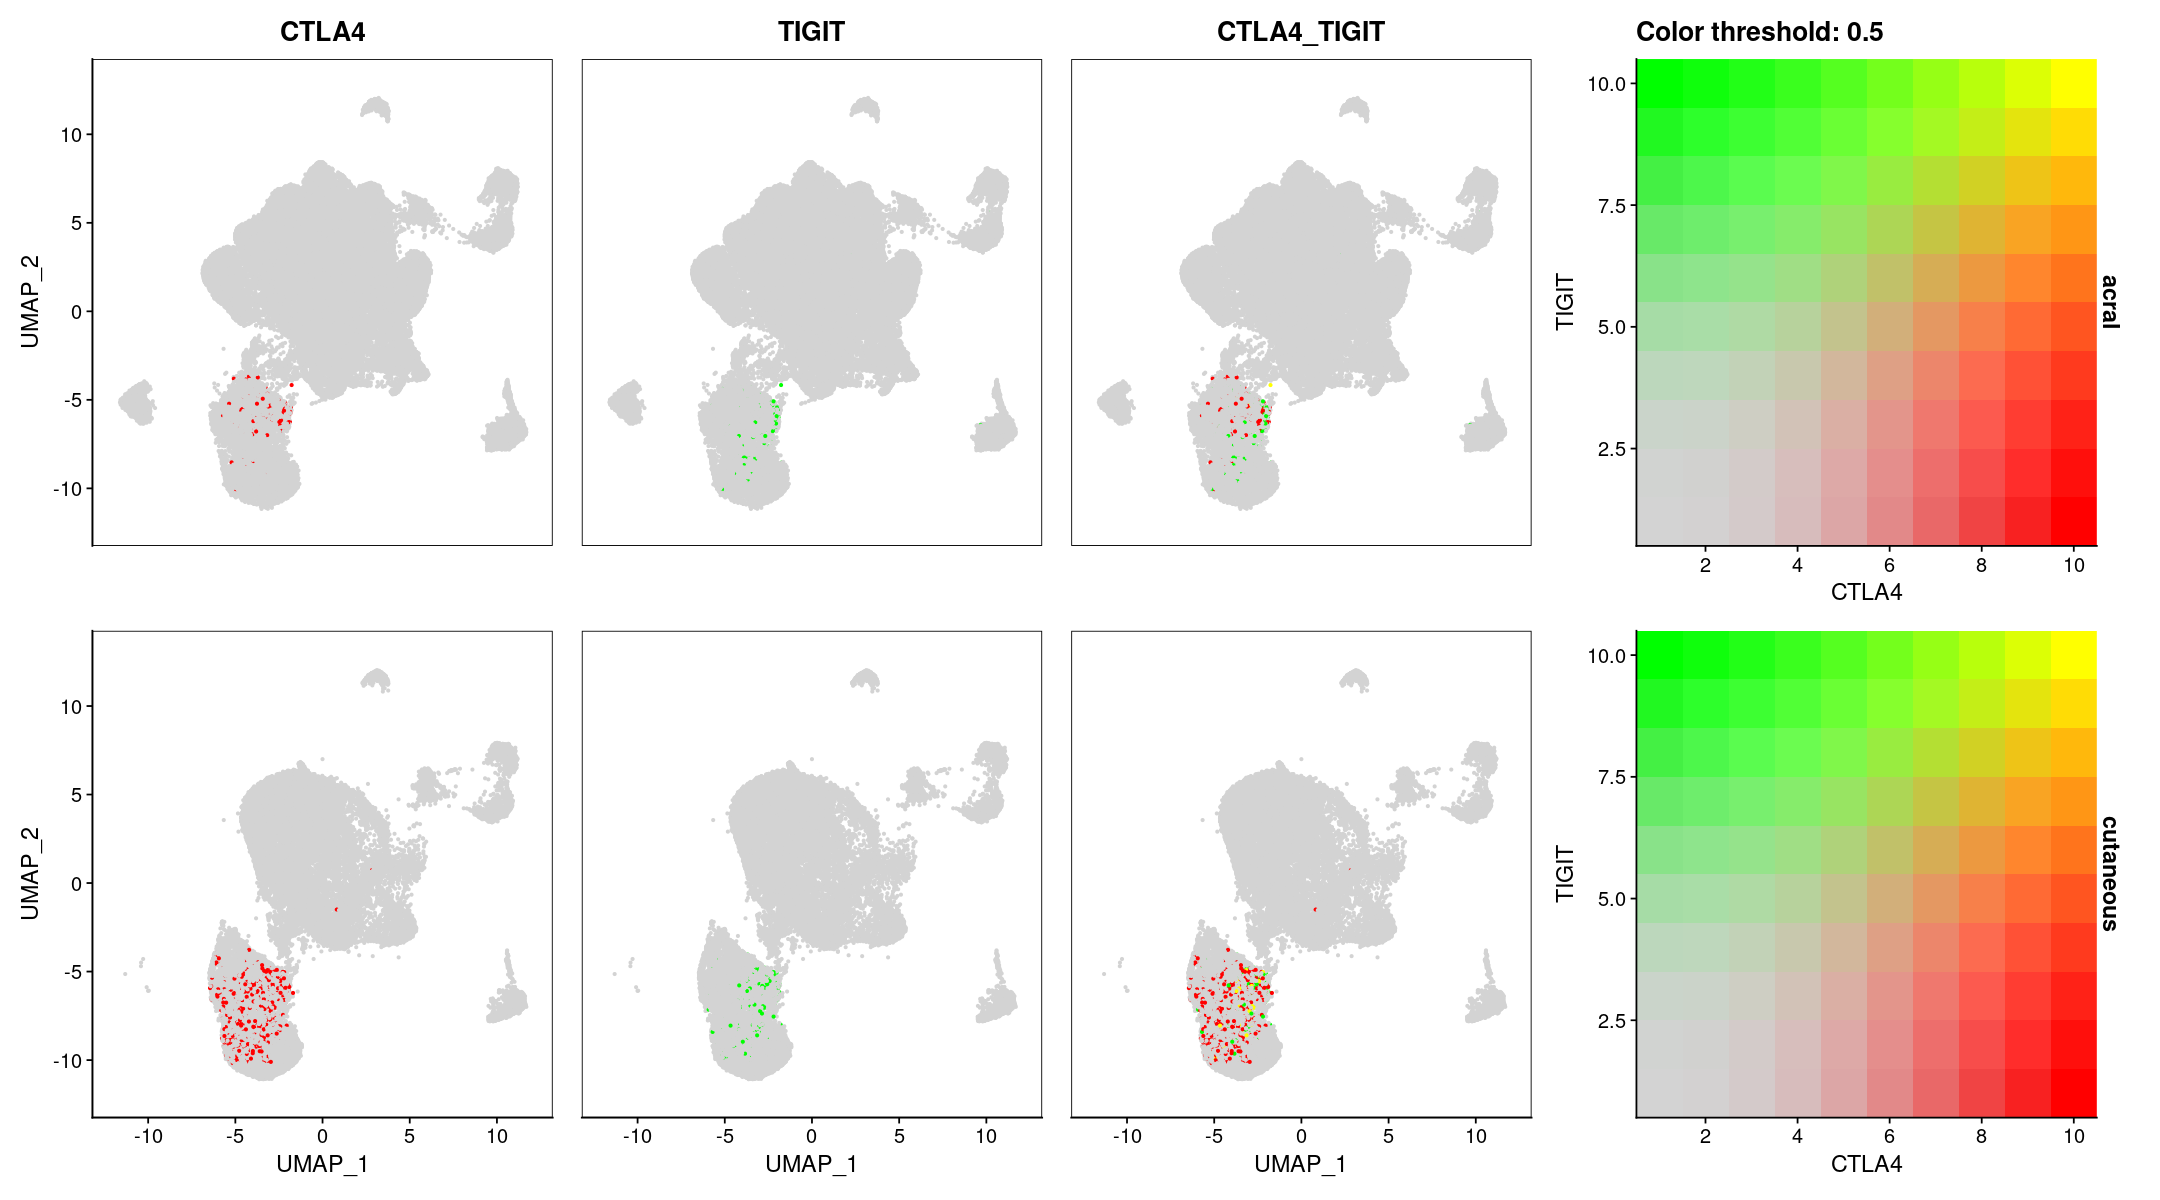

In [14]:
options(repr.plot.width = 18, repr.plot.height = 10)

genes <- c('CTLA4', 'TIGIT')
  
FeaturePlot(seu_obj_filtered, features = genes, split.by = 'ca_subtypes', pt.size = 0.5, blend = T)

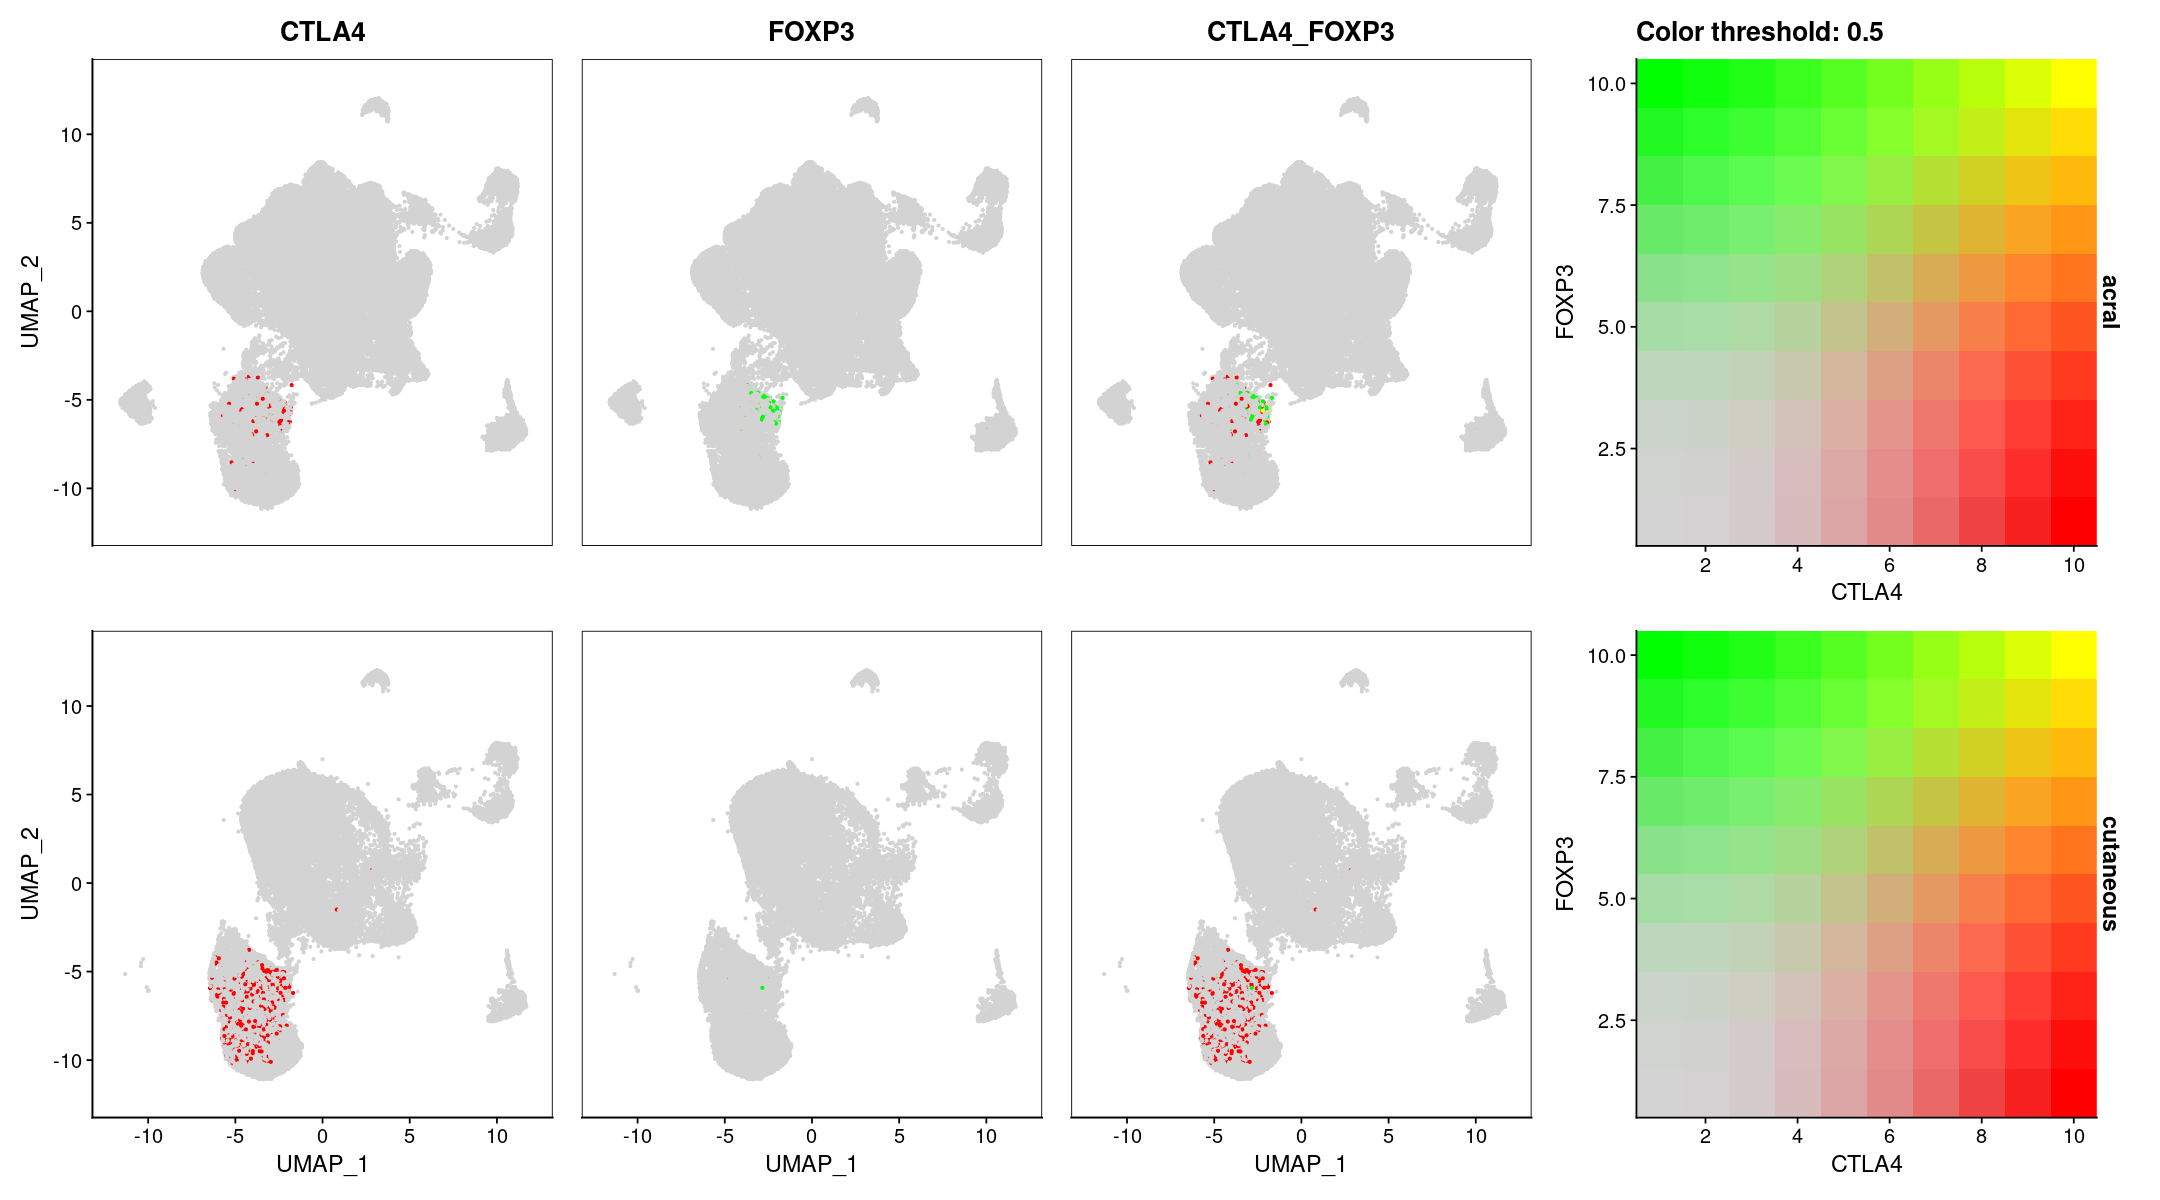

In [15]:
options(repr.plot.width = 18, repr.plot.height = 10)

genes <- c('CTLA4', 'FOXP3')
  
FeaturePlot(seu_obj_filtered, features = genes, split.by = 'ca_subtypes', pt.size = 0.5, blend = T)

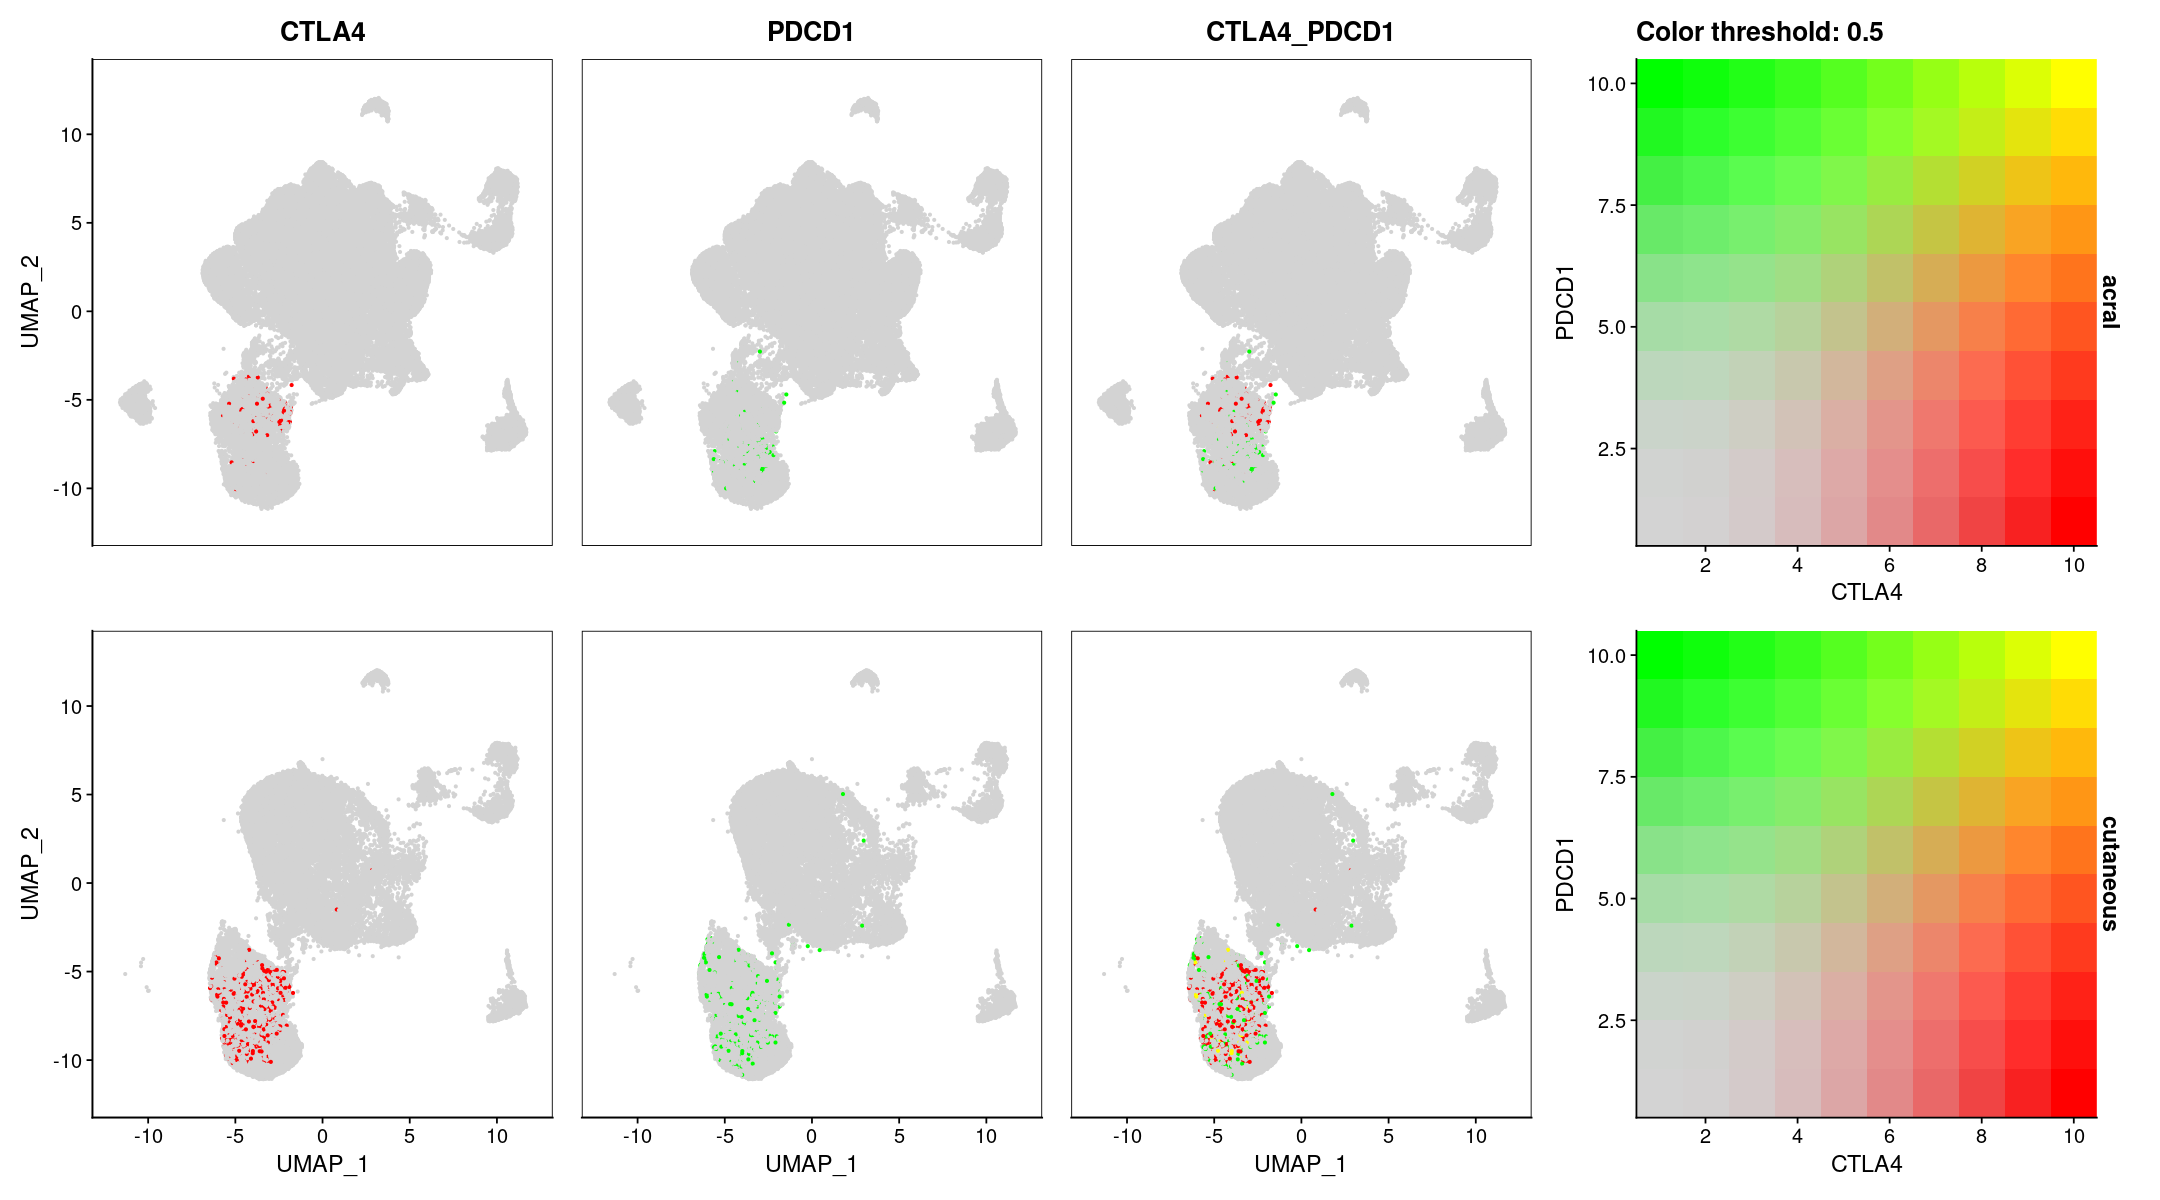

In [16]:
options(repr.plot.width = 18, repr.plot.height = 10)

genes <- c('CTLA4', 'PDCD1')
  
FeaturePlot(seu_obj_filtered, features = genes, split.by = 'ca_subtypes', pt.size = 0.5, blend = T)

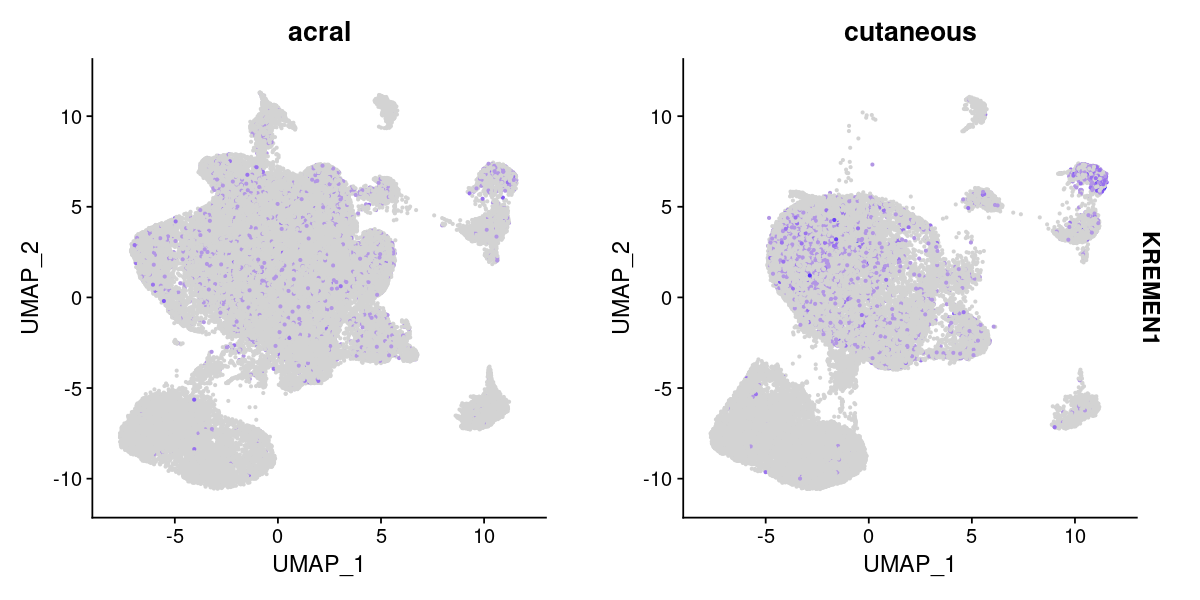

In [6]:
options(repr.plot.width = 10, repr.plot.height = 5)

gene <- 'KREMEN1'
  
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'ca_subtypes', pt.size = 0.5)
  


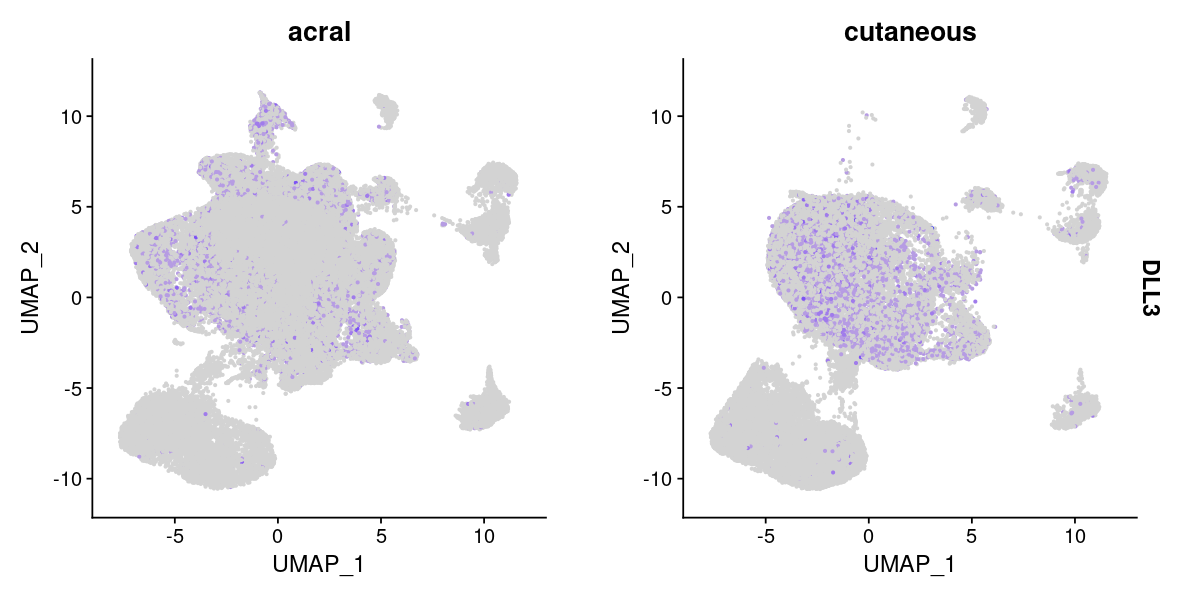

In [7]:
options(repr.plot.width = 10, repr.plot.height = 5)
gene <- 'DLL3'
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'ca_subtypes', pt.size = 0.5)

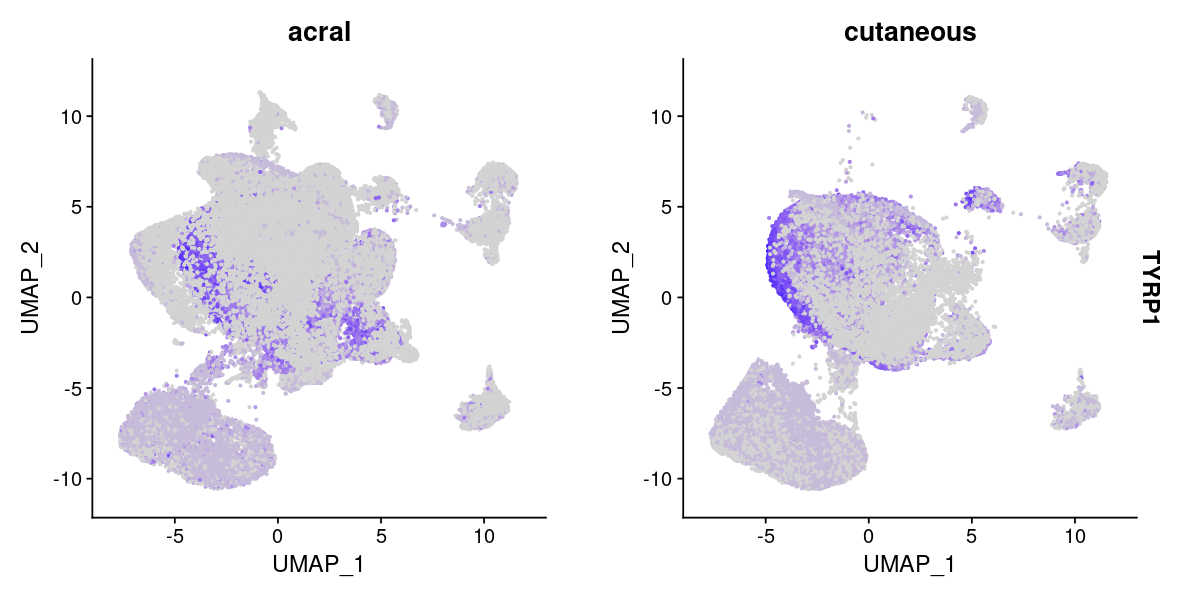

In [29]:
options(repr.plot.width = 10, repr.plot.height = 5)
gene <- 'TYRP1'
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'ca_subtypes', pt.size = 0.5)

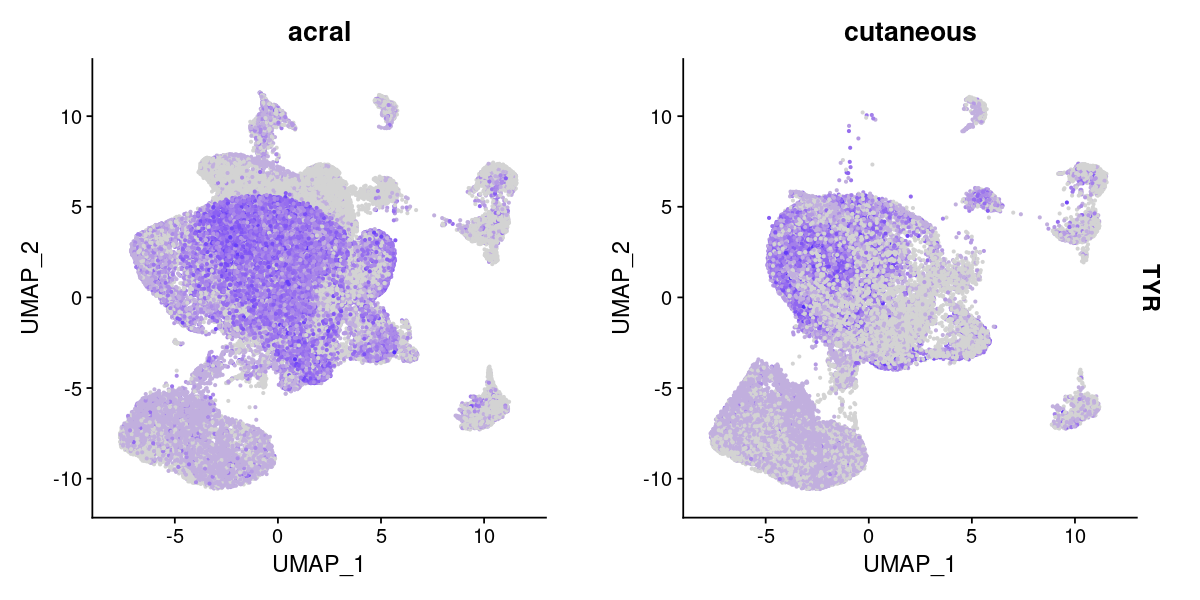

In [30]:
options(repr.plot.width = 10, repr.plot.height = 5)
gene <- 'TYR'
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'ca_subtypes', pt.size = 0.5)

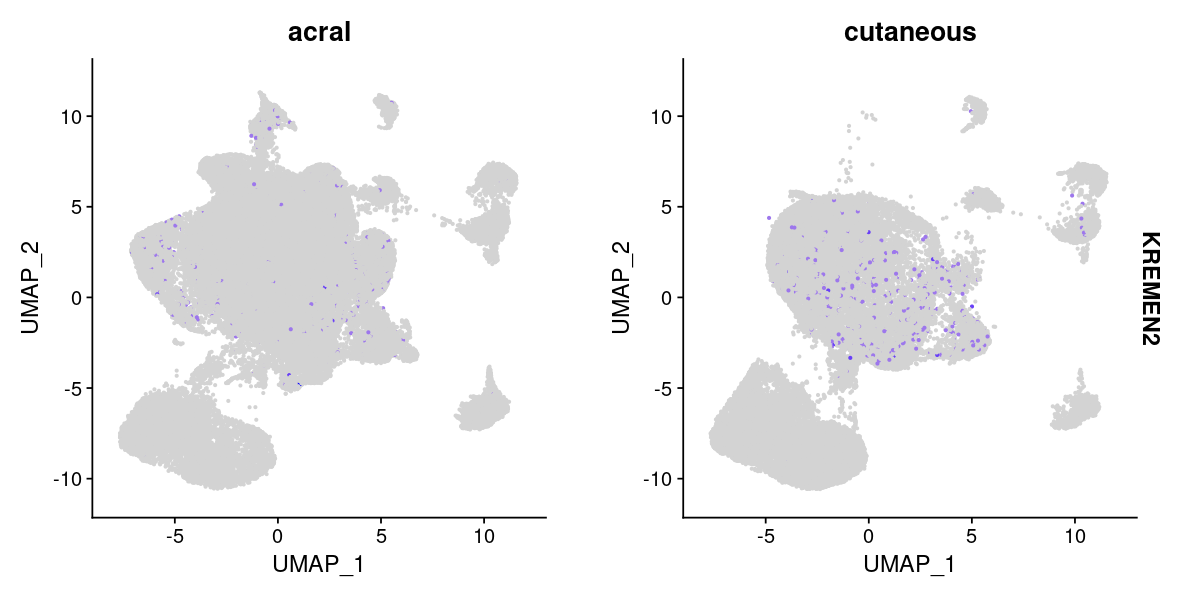

In [8]:
options(repr.plot.width = 10, repr.plot.height = 5)

gene <- 'KREMEN2'
  
FeaturePlot(seu_obj_filtered, features = gene, split.by = 'ca_subtypes', pt.size = 0.5)
  

In [6]:
gene_exp <- GetAssayData(object = seu_obj_filtered, slot = "data")

Picking joint bandwidth of 2.56e-06



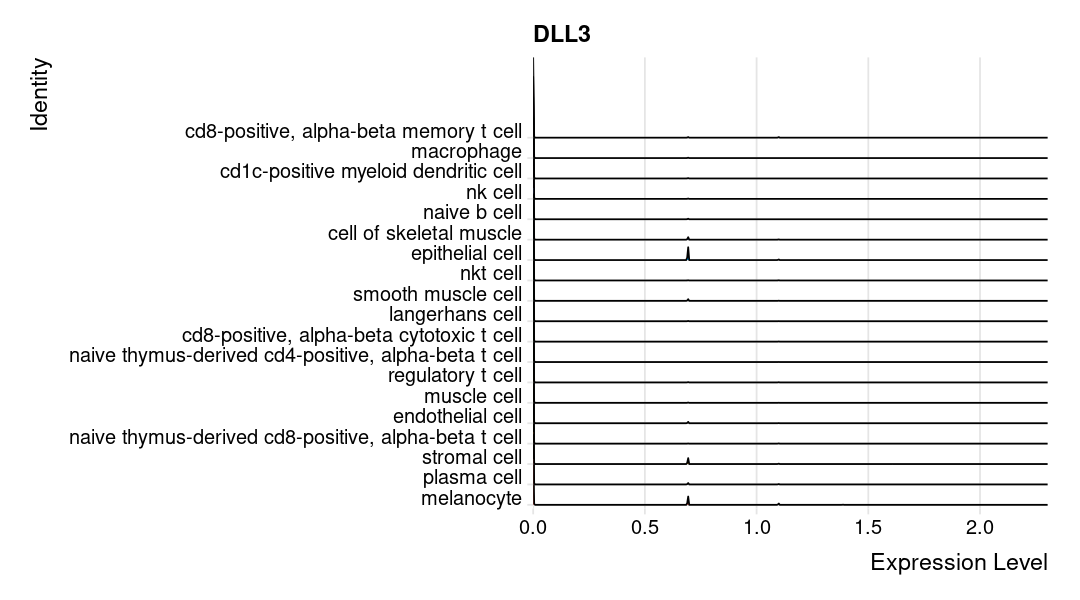

In [7]:
options(repr.plot.width = 9, repr.plot.height = 5)
# Idents(seu_obj_filtered)
cell.typs.filtered <- as.data.frame(table(seu_obj_filtered$cell.type), useNA = 'always') %>% filter(Freq > 100) %>% pull(Var1)
Idents(seu_obj_filtered) <- 'cell.type'
RidgePlot(subset(seu_obj_filtered, subset = cell.type %in% cell.typs.filtered), features = 'DLL3') +
theme(legend.position = 'none')

In [8]:
gene_exp_sub <- gene_exp['DLL3', ] %>% as.data.frame()
names(gene_exp_sub) <- 'Gene_exp'
gene_exp_sub$Gene_cat <- ifelse((gene_exp_sub$Gene_exp > 0), 'Positive', 'Negative')

In [9]:
df = merge(seu_obj_filtered@meta.data, gene_exp_sub, by = 'row.names')
head(df, 3)

,Row.names,orig.ident,nCount_RNA,nFeature_RNA,pMT,pHB,pRP,title,Tissue_type,ca_subtypes,⋯,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.1,SCT_snn_res.2,cell.type,Gene_exp,Gene_cat
,<I<chr>>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<chr>
1,GSM6622292_AAACCTGAGCAGCGTA-1,GSM6622292,34962,5254,12.708083,0,15.11355,melanoma scRNA Acral1,human tumor,acral,⋯,2,40,18,9,9,4,40,melanocyte,0,Negative
2,GSM6622292_AAACCTGAGCCCAATT-1,GSM6622292,2788,1032,1.470588,0,28.04878,melanoma scRNA Acral1,human tumor,acral,⋯,1,4,1,1,1,2,4,"cd8-positive, alpha-beta cytotoxic t cell",0,Negative
3,GSM6622292_AAACCTGAGGGTTCCC-1,GSM6622292,1866,824,1.500536,0,21.11468,melanoma scRNA Acral1,human tumor,acral,⋯,1,0,4,3,2,1,0,"cd8-positive, alpha-beta cytotoxic t cell",0,Negative


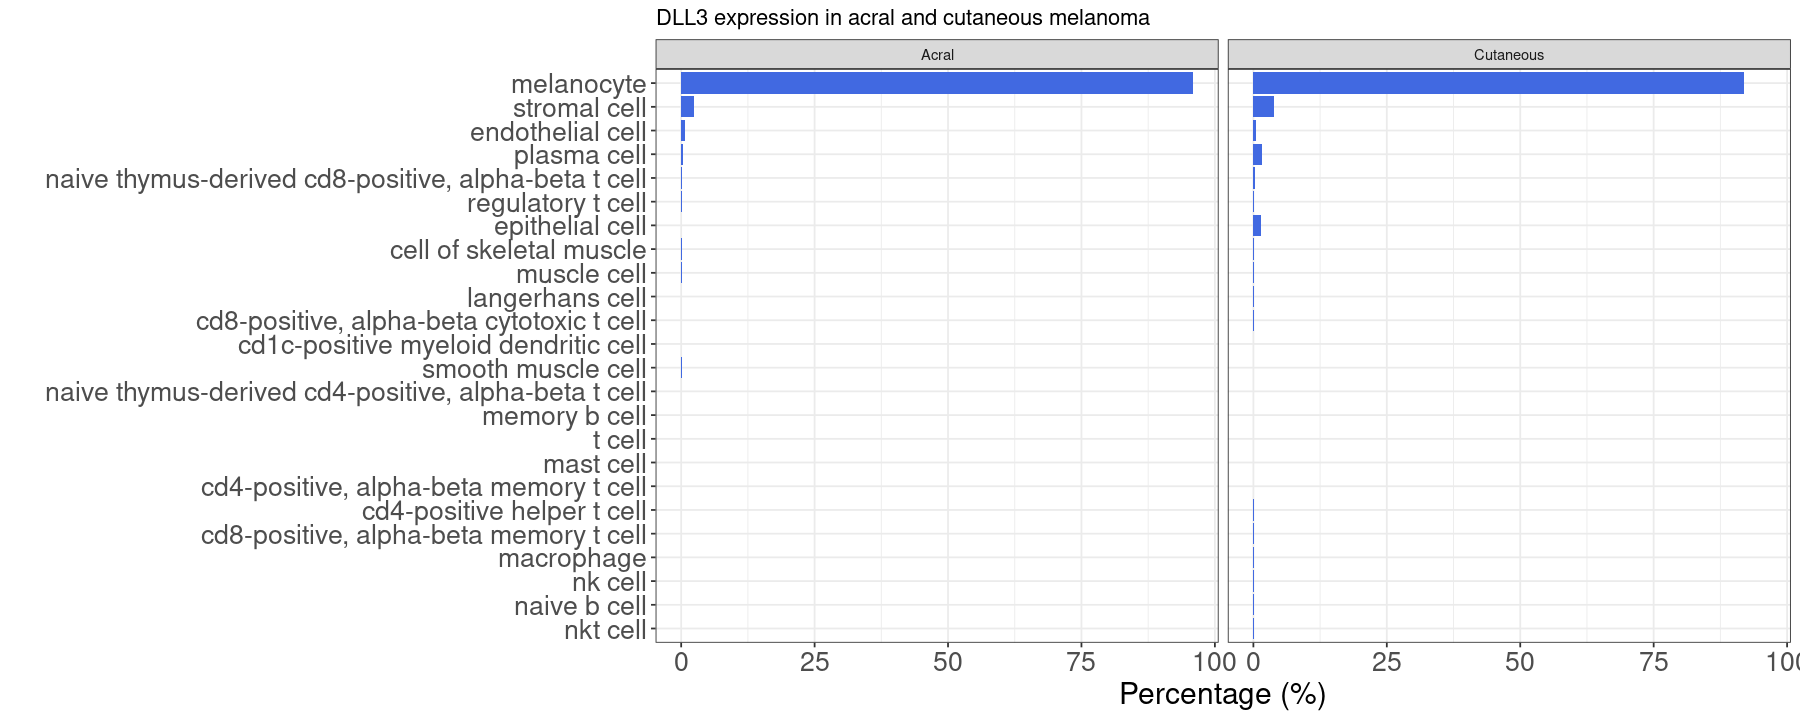

In [10]:
options(repr.plot.width = 15, repr.plot.height = 6)

df.acral <- df %>% filter((ca_subtypes == 'acral') & (Gene_cat == 'Positive') ) %>% {table( .$cell.type, .$Gene_cat)} %>% 
prop.table() %>% as.data.frame()
df.acral$ca_subtype <- 'Acral'

df.cutaneous <- df %>% filter((ca_subtypes == 'cutaneous') & (Gene_cat == 'Positive')) %>% {table( .$cell.type, .$Gene_cat)} %>% 
prop.table() %>% as.data.frame() 
df.cutaneous$ca_subtype <- 'Cutaneous'

cell.sorted <- levels(df.cutaneous$cell.type)

plot.df <- rbind(df.acral, df.cutaneous) %>% filter(Var2 == 'Positive') %>% arrange(Freq) 
plot.df$Freq <- plot.df$Freq * 100
cell.sorted <- unique(plot.df$Var1)
plot.df$Var1 <- factor(plot.df$Var1, levels = cell.sorted)

ggplot(plot.df, aes(x = Var1, y = Freq)) +
geom_bar(stat = 'identity', fill = 'royalblue') + facet_wrap(~ca_subtype) +
coord_flip() +
theme_bw() +
    theme(axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),  
        axis.title.x = element_text( size = 18),
        axis.title.y = element_text(size = 18), 
          legend.position="none") +
    labs(title = 'DLL3 expression in acral and cutaneous melanoma',
        x = "",
        y = "Percentage (%)")

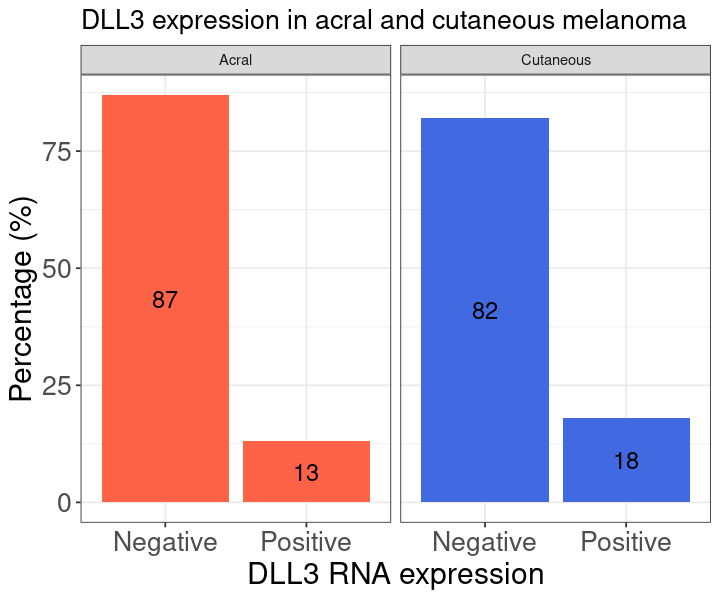

In [11]:
options(repr.plot.width = 6, repr.plot.height = 5)
# df.melanoma <-
df.m1 <- df %>% filter((cell.type == 'melanocyte') & (ca_subtypes == 'acral')) %>% {table(.$Gene_cat)} %>%
prop.table() %>% as.data.frame()
df.m1$ca_subtype <- 'Acral'

df.m2 <- df %>% filter((cell.type == 'melanocyte') & (ca_subtypes == 'cutaneous')) %>% {table(.$Gene_cat)} %>% 
prop.table() %>% as.data.frame()
df.m2$ca_subtype <- 'Cutaneous'
plot.df2 <- rbind(df.m1, df.m2)
plot.df2$Freq <- round(plot.df2$Freq * 100, 0)

ggplot(plot.df2, aes(x = Var1, y = Freq, fill = ca_subtype, label = Freq)) +
geom_bar(stat = 'identity') + facet_wrap(~ca_subtype) +
geom_text(size = 5, position = position_stack(vjust = 0.5)) +
scale_fill_manual(values=c( "tomato", "royalblue"))+
# coord_flip() +
theme_bw() +
    theme(axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),  
        axis.title.x = element_text( size = 18),
        axis.title.y = element_text(size = 18), 
          plot.title = element_text(size=16),
          legend.position="none") +
    labs(title = 'DLL3 expression in acral and cutaneous melanoma',
        x = "DLL3 RNA expression",
        y = "Percentage (%)")

In [12]:
# Coexpression analysis of DLL3 + malanoma cancer cells
gene_exp[1:3, 1:3]

3 x 3 sparse Matrix of class "dgCMatrix"
            GSM6622292_AAACCTGAGCAGCGTA-1 GSM6622292_AAACCTGAGCCCAATT-1
MIR1302-2HG                             .                             .
OR4F5                                   .                             .
AL627309.1                              .                             .
            GSM6622292_AAACCTGAGGGTTCCC-1
MIR1302-2HG                             .
OR4F5                                   .
AL627309.1                              .

In [13]:
melanoma.dll3 <- df %>% filter((Gene_cat == 'Positive') & (cell.type == 'melanocyte'))
melanoma.dll3 <- melanoma.dll3$Row.names

df.co.exp <- gene_exp[, colnames(gene_exp) %in% melanoma.dll3]
gene_list <- rownames(df.co.exp) %>% unique()
gene_list <- gene_list[!gene_list %in% 'DLL3']




In [26]:
G <- 'DLL3'
res.df <- NULL
for(i in 1:length(gene_list)){
    
    G_ <- gene_list[i]

    df.analysis <- df.co.exp[c(G, G_), ] %>% t()
    
    corr_test <- tryCatch({
            corr <- cor(df.analysis[, G], df.analysis[, G_], method = 'spearman')
            p <- cor.test(df.analysis[, G], df.analysis[, G_], method = 'spearman', exact = F)
            p <- p$p.value
            res <- data.frame(Gene = G, Gene2 = G_, Correlation = corr, p.Value = p)
            res.df <- rbind(res.df, res)
    
    # }, error = function(e) {})
    }, warning = function(w) {})

    
}


In [27]:
res.df %>% arrange(desc(Correlation)) %>% head(50)

,Gene,Gene2,Correlation,p.Value
,<chr>,<chr>,<dbl>,<dbl>
1,DLL3,TYRP1,0.09979526,1.034041e-24
2,DLL3,TYR,0.09288316,1.309739e-21
3,DLL3,IFI27,0.07595512,6.042278e-15
4,DLL3,TMA7,0.07238754,1.041204e-13
5,DLL3,IFITM1,0.07138957,2.254057e-13
6,DLL3,C9orf16,0.07130695,2.401773e-13
7,DLL3,RPS17,0.07079668,3.548878e-13
8,DLL3,PABPC1,0.06990419,6.979125e-13
9,DLL3,IFITM3,0.06986506,7.187800e-13
